# European Bird Sightings Analysis
## Combining and Analyzing eBird Data from 47 European Countries

This notebook will:
1. Combine all your CSV files into one dataset
2. Perform comprehensive statistical analysis
3. Create visualizations
4. Export results

---

## Setup and Imports

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from datetime import datetime
import geopandas as gpd

warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## 2. Data Preprocessing

In [2]:
combined_df = pd.read_csv("/Users/dazedinthecity/Documents/GitHub/ceu-ds-project-groupB-2026/ebird/migra_species_europe_only.csv")
combined_df.shape

(878189, 20)

In [3]:
# Convert date column to datetime
combined_df['obsDt'] = pd.to_datetime(combined_df['OBSERVATION DATE'], errors='coerce')

# Extract temporal features
combined_df['year'] = combined_df['obsDt'].dt.year
combined_df['month'] = combined_df['obsDt'].dt.month
combined_df['day_of_week'] = combined_df['obsDt'].dt.dayofweek
combined_df['day_of_year'] = combined_df['obsDt'].dt.dayofyear

# drop 2026 (it ruins the results)
combined_df = combined_df[combined_df['year'] < 2023]

# Convert count to numeric
combined_df['howMany'] = pd.to_numeric(combined_df['OBSERVATION COUNT'], errors='coerce')

print("✓ Data preprocessing complete!")
print(f"\nDate range: {combined_df['obsDt'].min()} to {combined_df['obsDt'].max()}")
print(f"Years covered: {sorted(combined_df['year'].dropna().unique().astype(int).tolist())}")

✓ Data preprocessing complete!

Date range: 2017-01-01 00:00:00 to 2022-12-31 00:00:00
Years covered: [2017, 2018, 2019, 2020, 2021, 2022]


## 3. Basic Statistics

In [4]:
# Overall statistics
print("="*80)
print("OVERALL DATASET STATISTICS")
print("="*80)
print(f"\nTotal observations: {len(combined_df):,}")
print(f"Number of countries: {combined_df['COUNTRY CODE'].nunique()}")
print(f"Number of states/regions: {combined_df['STATE CODE'].nunique()}")
print(f"Number of counties: {combined_df['COUNTY CODE'].nunique()}")
print(f"Number of unique species: {combined_df['SCIENTIFIC NAME'].nunique()}")
print(f"Number of locality types: {combined_df['LOCALITY TYPE'].nunique()}")
print(f"Number of observation types: {combined_df['OBSERVATION TYPE'].nunique()}")
print(f"Number of unique observers: {combined_df['OBSERVER ID'].nunique()}")

# Count data statistics
count_data = combined_df[combined_df['howMany'].notna()]
print(f"\nObservations with count data: {len(count_data):,} ({len(count_data)/len(combined_df)*100:.1f}%)")
if len(count_data) > 0:
    print(f"Total birds counted: {count_data['howMany'].sum():,.0f}")
    print(f"Average count per observation: {count_data['howMany'].mean():.2f}")
    print(f"Median count: {count_data['howMany'].median():.0f}")
    print(f"Maximum count in single observation: {count_data['howMany'].max():,.0f}")
    print(f"Minimum count: {count_data['howMany'].min():.0f}")

OVERALL DATASET STATISTICS

Total observations: 690,526
Number of countries: 46
Number of states/regions: 669
Number of counties: 1043
Number of unique species: 11
Number of locality types: 2
Number of observation types: 8
Number of unique observers: 19323

Observations with count data: 690,526 (100.0%)
Total birds counted: 15,355,201
Average count per observation: 22.24
Median count: 2
Maximum count in single observation: 140,000
Minimum count: 1


### outlier removal for col 'howMany'

In [5]:
Q1 = combined_df['howMany'].quantile(0.25)
Q3 = combined_df['howMany'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = combined_df[(combined_df['howMany'] < lower_bound) | (combined_df['howMany'] > upper_bound)]

print("="*80)
print("OUTLIER ANALYSIS: howMany")
print("="*80)
print(f"\nQ1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f"\nTotal outliers: {len(outliers):,} ({len(outliers)/len(combined_df)*100:.2f}% of data)")
print(f"\nOutlier summary:")
print(outliers['howMany'].describe())

OUTLIER ANALYSIS: howMany

Q1: 1.0
Q3: 5.0
IQR: 4.0
Lower bound: -5.0
Upper bound: 11.0

Total outliers: 90,888 (13.16% of data)

Outlier summary:
count     90888.000000
mean        152.053065
std        2037.232393
min          12.000000
25%          16.000000
50%          25.000000
75%          50.000000
max      140000.000000
Name: howMany, dtype: float64


In [6]:
print("="*80)
print("OUTLIER DISTRIBUTION: howMany")
print("="*80)

# Value counts for outliers
outlier_dist = outliers['howMany'].value_counts().sort_index()

print(f"\nTop 20 most frequent outlier values:")
print(outliers['howMany'].value_counts().head(20))

print(f"\nOutlier range distribution (binned):")
bins = [lower_bound, 50, 100, 500, 1000, 5000, float('inf')]
labels = [f'{int(lower_bound)}-50', '51-100', '101-500', '501-1000', '1001-5000', '5000+']
outlier_binned = pd.cut(outliers['howMany'], bins=bins, labels=labels)
print(outlier_binned.value_counts().sort_index())

print(f"\nKey outlier statistics:")
print(f"  Min outlier value:    {outliers['howMany'].min():,.0f}")
print(f"  Max outlier value:    {outliers['howMany'].max():,.0f}")
print(f"  Mean outlier value:   {outliers['howMany'].mean():,.2f}")
print(f"  Median outlier value: {outliers['howMany'].median():,.0f}")

OUTLIER DISTRIBUTION: howMany

Top 20 most frequent outlier values:
howMany
20.0     8475
15.0     7197
12.0     7191
30.0     5540
50.0     3810
25.0     3650
14.0     3413
40.0     3175
13.0     2833
16.0     2575
18.0     2289
100.0    2072
17.0     1911
60.0     1693
35.0     1576
22.0     1351
19.0     1310
80.0     1149
21.0     1143
200.0    1142
Name: count, dtype: int64

Outlier range distribution (binned):
howMany
-5-50        69064
51-100       11302
101-500       8563
501-1000       885
1001-5000      816
5000+          258
Name: count, dtype: int64

Key outlier statistics:
  Min outlier value:    12
  Max outlier value:    140,000
  Mean outlier value:   152.05
  Median outlier value: 25


In [7]:
high_outliers = outliers[outliers['howMany'] > 100]

print("="*80)
print("LOCALITY TYPES FOR OUTLIERS WHERE howMany > 100")
print("="*80)
print(f"\nTotal rows with howMany > 100: {len(high_outliers):,}")
print(f"\nLocality Type Distribution:")
print(high_outliers['LOCALITY TYPE'].value_counts())
print(f"\nLocality Type Proportions:")
print(high_outliers['LOCALITY TYPE'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

LOCALITY TYPES FOR OUTLIERS WHERE howMany > 100

Total rows with howMany > 100: 10,522

Locality Type Distribution:
LOCALITY TYPE
H    8571
P    1951
Name: count, dtype: int64

Locality Type Proportions:
LOCALITY TYPE
H    81.46%
P    18.54%
Name: proportion, dtype: object


#### dropping outliers

In [8]:
before = len(combined_df)
combined_df = combined_df[combined_df['howMany'] <= 100]
after = len(combined_df)

print("="*80)
print("AFTER DROPPING howMany > 100")
print("="*80)
print(f"\nRows before: {before:,}")
print(f"Rows after:  {after:,}")
print(f"Rows dropped: {before - after:,} ({(before - after)/before*100:.2f}% of data)")

AFTER DROPPING howMany > 100

Rows before: 690,526
Rows after:  680,004
Rows dropped: 10,522 (1.52% of data)


## 4. Analysis by Country

In [9]:
print(combined_df['STATE'].isna().sum(),combined_df['COUNTY'].isna().sum())

0 217584


In [10]:
country_stats = combined_df.groupby(['COUNTRY CODE', 'COUNTRY']).agg(
    total_observations=('SAMPLING EVENT IDENTIFIER', 'count'),
    unique_species=('SCIENTIFIC NAME', 'nunique'),
    unique_states=('STATE', 'nunique'),
    unique_counties=('COUNTY', 'nunique'),
    total_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).reset_index()

country_stats.columns = ['Country Code', 'Country Name', 'Total Observations', 
                         'Unique Species', 'Unique States', 'Unique Counties', 
                         'Total Birds Counted']

country_stats = country_stats.sort_values('Total Observations', ascending=False)

print("\nSTATISTICS BY COUNTRY")
print("="*120)
print(country_stats.to_string(index=False))


STATISTICS BY COUNTRY
Country Code           Country Name  Total Observations  Unique Species  Unique States  Unique Counties  Total Birds Counted
          ES                  Spain              212295              11             19               48            1162672.0
          GB         United Kingdom              116040              11              4              103             632771.0
          PT               Portugal               76561              11             20              278             467789.0
          FR                 France               28733              11             13               96             160878.0
          DE                Germany               28532              11             16              327             156647.0
          PL                 Poland               21825              10             16                0             170154.0
          SE                 Sweden               21432              11             21                

In [11]:
country_stats = combined_df.groupby(['COUNTRY CODE', 'COUNTRY']).agg(
    total_observations=('SAMPLING EVENT IDENTIFIER', 'count'),
    unique_species=('SCIENTIFIC NAME', 'nunique'),
    unique_states=('STATE', 'nunique'),
    unique_counties=('COUNTY', 'nunique'),
    total_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0),
    unique_observers=('OBSERVER ID', 'nunique')
).reset_index()

country_stats.columns = ['Country Code', 'Country Name', 'Total Observations', 
                         'Unique Species', 'Unique States', 'Unique Counties', 
                         'Total Birds Counted', 'Unique Observers']

country_stats = country_stats.sort_values('Unique Observers', ascending=False)

print("\nSTATISTICS BY COUNTRY")
print("="*120)
print(country_stats.to_string(index=False))


STATISTICS BY COUNTRY
Country Code           Country Name  Total Observations  Unique Species  Unique States  Unique Counties  Total Birds Counted  Unique Observers
          ES                  Spain              212295              11             19               48            1162672.0              6298
          GB         United Kingdom              116040              11              4              103             632771.0              4620
          PT               Portugal               76561              11             20              278             467789.0              2508
          FR                 France               28733              11             13               96             160878.0              1913
          DE                Germany               28532              11             16              327             156647.0              1386
          NL            Netherlands               13310              11             12                2              82

## 5. Species Analysis

In [12]:
# Species statistics
species_stats = combined_df.groupby(['COMMON NAME', 'SCIENTIFIC NAME']).agg({
    'SAMPLING EVENT IDENTIFIER': 'count',
    'COUNTRY CODE': 'nunique',
    'STATE CODE': 'nunique',
    'howMany': lambda x: x.sum() if x.notna().any() else 0
}).reset_index()

species_stats.columns = ['Common Name', 'Scientific Name', 
                        'Total Observations', 'Countries Found', 'States Found', 'Total Count']

species_stats = species_stats.sort_values('Total Observations', ascending=False)

print("\nTOP 30 MOST OBSERVED SPECIES")
print("="*120)
print(species_stats.head(30).to_string(index=False))


TOP 30 MOST OBSERVED SPECIES
           Common Name     Scientific Name  Total Observations  Countries Found  States Found  Total Count
       Green Sandpiper     Tringa ochropus              173660               44           557     413116.0
                  Ruff     Calidris pugnax              109964               42           491     951843.0
            Sanderling       Calidris alba               85484               42           305     984336.0
        Wood Sandpiper     Tringa glareola               74871               42           523     418857.0
              Garganey Spatula querquedula               52675               43           511     233464.0
          Little Stint     Calidris minuta               51689               43           383     286413.0
European Honey-buzzard     Pernis apivorus               44529               42           545     208528.0
              Red Knot    Calidris canutus               39126               40           273     316233.0
      C

## 6. Temporal Analysis


TEMPORAL ANALYSIS

Observations by Year:
  2017: 61,361
  2018: 72,027
  2019: 93,957
  2020: 105,754
  2021: 149,076
  2022: 197,829

Observations by month of 2017
  January: 2,879
  February: 1,809
  March: 3,876
  April: 7,811
  May: 7,059
  June: 2,655
  July: 4,694
  August: 9,522
  September: 10,022
  October: 5,289
  November: 2,767
  December: 2,978
  → Peak migration month: September (10,022 observations)

Observations by month of 2018
  January: 3,580
  February: 2,813
  March: 4,391
  April: 8,318
  May: 10,164
  June: 3,551
  July: 6,526
  August: 10,991
  September: 10,790
  October: 4,735
  November: 2,869
  December: 3,299
  → Peak migration month: August (10,991 observations)

Observations by month of 2019
  January: 4,167
  February: 3,267
  March: 6,926
  April: 12,293
  May: 11,497
  June: 3,968
  July: 8,252
  August: 15,292
  September: 14,045
  October: 6,311
  November: 3,876
  December: 4,063
  → Peak migration month: August (15,292 observations)

Observations 

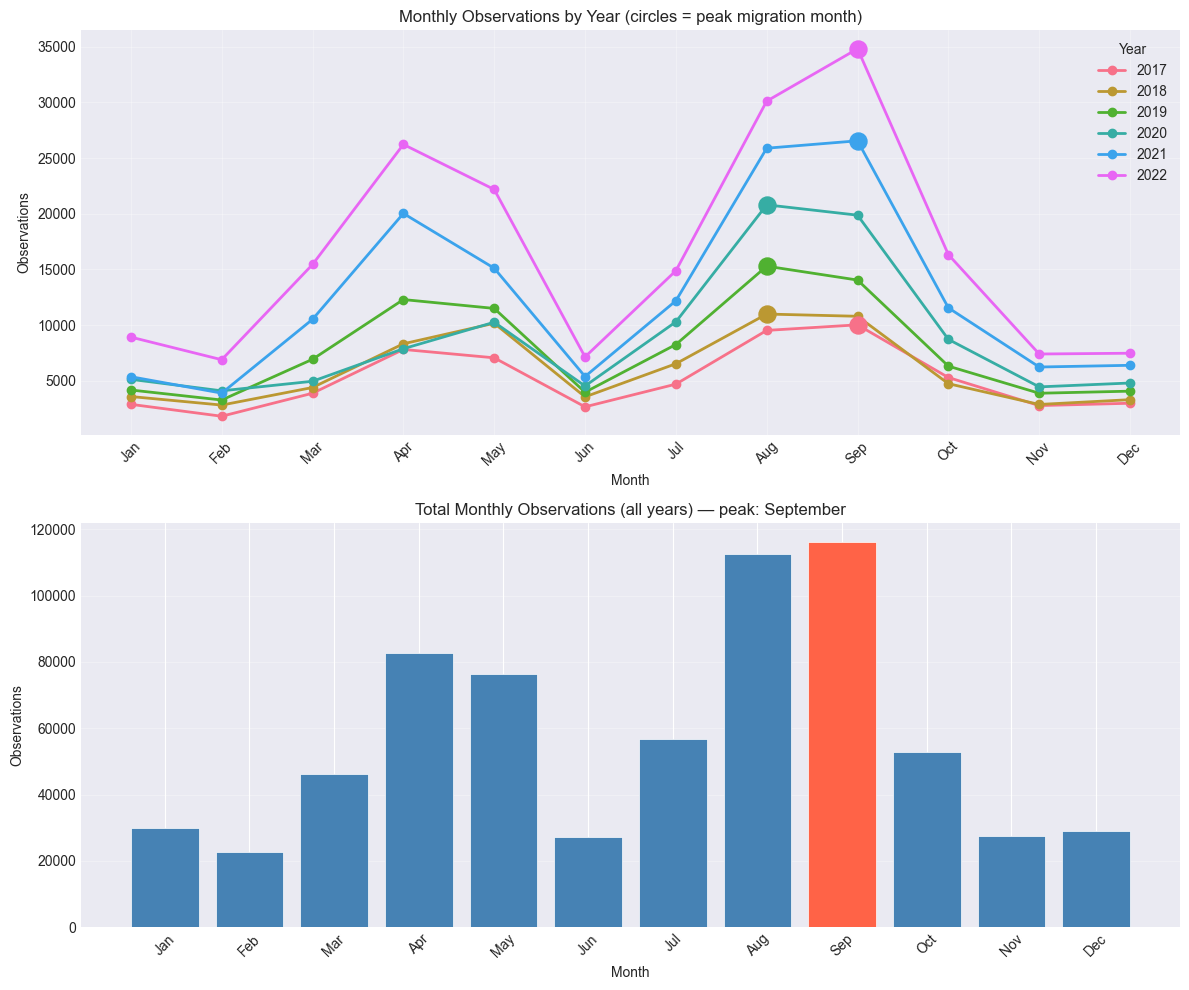

In [13]:
# Temporal distribution
print("\nTEMPORAL ANALYSIS")
print("="*60)

# By year
yearly_obs = combined_df.groupby('year').size().sort_index()
print("\nObservations by Year:")
for year, count in yearly_obs.items():
    if pd.notna(year):
        print(f"  {int(year)}: {count:,}")

# Month each year
month_names = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
               7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}

peak_months_by_year = {}  # store peak month per year

yearly_obs = combined_df.groupby('year').size().sort_index()
for year in yearly_obs.index:
    print("\nObservations by month of", int(year))
    monthly_obs = combined_df[combined_df['year'] == year].groupby('month').size().sort_index()
    for month, count in monthly_obs.items():
        if pd.notna(month):
            print(f"  {month_names[int(month)]}: {count:,}")
    
    # Save peak month for this year
    peak_month = monthly_obs.idxmax()
    if pd.notna(peak_month):
        peak_months_by_year[int(year)] = {
            'month': int(peak_month),
            'month_name': month_names[int(peak_month)],
            'count': monthly_obs.max()
        }
        print(f"  → Peak migration month: {month_names[int(peak_month)]} ({monthly_obs.max():,} observations)")

# By month (all years combined)
monthly_obs = combined_df.groupby('month').size().sort_index()
print("\nObservations by Month (all years):")
for month, count in monthly_obs.items():
    if pd.notna(month):
        print(f"  {month_names[int(month)]}: {count:,}")

# Peak observation period
peak_month = monthly_obs.idxmax()
if pd.notna(peak_month):
    print(f"\nPeak observation month: {month_names[int(peak_month)]} ({monthly_obs.max():,} observations)")

# Print summary of peak months
print("\nPeak Migration Month by Year:")
for year, info in peak_months_by_year.items():
    print(f"  {year}: {info['month_name']} ({info['count']:,} observations)")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Monthly observations per year (lines)
ax1 = axes[0]
for year in yearly_obs.index:
    if pd.notna(year):
        monthly = combined_df[combined_df['year'] == year].groupby('month').size().reindex(range(1, 13), fill_value=0)
        ax1.plot(range(1, 13), monthly.values, marker='o', label=str(int(year)), linewidth=2)
        # Mark peak month
        if int(year) in peak_months_by_year:
            pm = peak_months_by_year[int(year)]['month']
            ax1.scatter(pm, monthly[pm], s=150, zorder=5)

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels([month_names[m][:3] for m in range(1, 13)], rotation=45)
ax1.set_title('Monthly Observations by Year (circles = peak migration month)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Observations')
ax1.legend(title='Year')
ax1.grid(True, alpha=0.3)

# Plot 2: Combined monthly observations (bar)
ax2 = axes[1]
colors = ['tomato' if m == int(peak_month) else 'steelblue' for m in range(1, 13)]
monthly_all = combined_df.groupby('month').size().reindex(range(1, 13), fill_value=0)
bars = ax2.bar(range(1, 13), monthly_all.values, color=colors, edgecolor='white', linewidth=0.5)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels([month_names[m][:3] for m in range(1, 13)], rotation=45)
ax2.set_title(f'Total Monthly Observations (all years) — peak: {month_names[int(peak_month)]}')
ax2.set_xlabel('Month')
ax2.set_ylabel('Observations')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
#plt.savefig('temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
#print("\nPlot saved as 'temporal_analysis.png'")

In [14]:
# Temporal distribution
print("\nTEMPORAL ANALYSIS")
print("="*60)

# By year
yearly_obs = combined_df.groupby('year').agg(
    observations=('OBSERVER ID', 'count'),
    number_of_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).sort_index()

print("\nObservations by Year:")
for year, row in yearly_obs.iterrows():
    if pd.notna(year):
        print(f"  {int(year)}: {row['observations']:,} observations | {row['number_of_birds']:,} number of birds counted")
        #print(f"    Avg obs per observer: {(row['observations'] / row['unique_observers']):.2f}")




TEMPORAL ANALYSIS

Observations by Year:
  2017: 61,361.0 observations | 360,097.0 number of birds counted
  2018: 72,027.0 observations | 435,842.0 number of birds counted
  2019: 93,957.0 observations | 557,127.0 number of birds counted
  2020: 105,754.0 observations | 635,032.0 number of birds counted
  2021: 149,076.0 observations | 889,602.0 number of birds counted
  2022: 197,829.0 observations | 1,165,601.0 number of birds counted


In [15]:
# temporal analysis relative to the number of observers
print("\nTEMPORAL ANALYSIS")
print("="*60)

# By year
yearly_obs = combined_df.groupby('year').agg(
    observations=('OBSERVER ID', 'count'),
    unique_observers=('OBSERVER ID', 'nunique'),
    number_of_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).sort_index()

print("\nObservations by Year:")
for year, row in yearly_obs.iterrows():
    if pd.notna(year):
        # print(f"  {int(year)}: {row['number_of_birds']:,} number of birds counted | {row['unique_observers']:,} unique observers")
        print(f"    Avg bird per observer: {(row['number_of_birds'] / row['unique_observers']):.2f}")
        # print(f"  {int(year)}: {row['observations']:,} observations | {row['unique_observers']:,} unique observers")
        print(f"    Avg obs per observer: {(row['observations'] / row['unique_observers']):.2f}")




TEMPORAL ANALYSIS

Observations by Year:
    Avg bird per observer: 85.21
    Avg obs per observer: 14.52
    Avg bird per observer: 82.59
    Avg obs per observer: 13.65
    Avg bird per observer: 86.73
    Avg obs per observer: 14.63
    Avg bird per observer: 102.54
    Avg obs per observer: 17.08
    Avg bird per observer: 106.41
    Avg obs per observer: 17.83
    Avg bird per observer: 103.06
    Avg obs per observer: 17.49


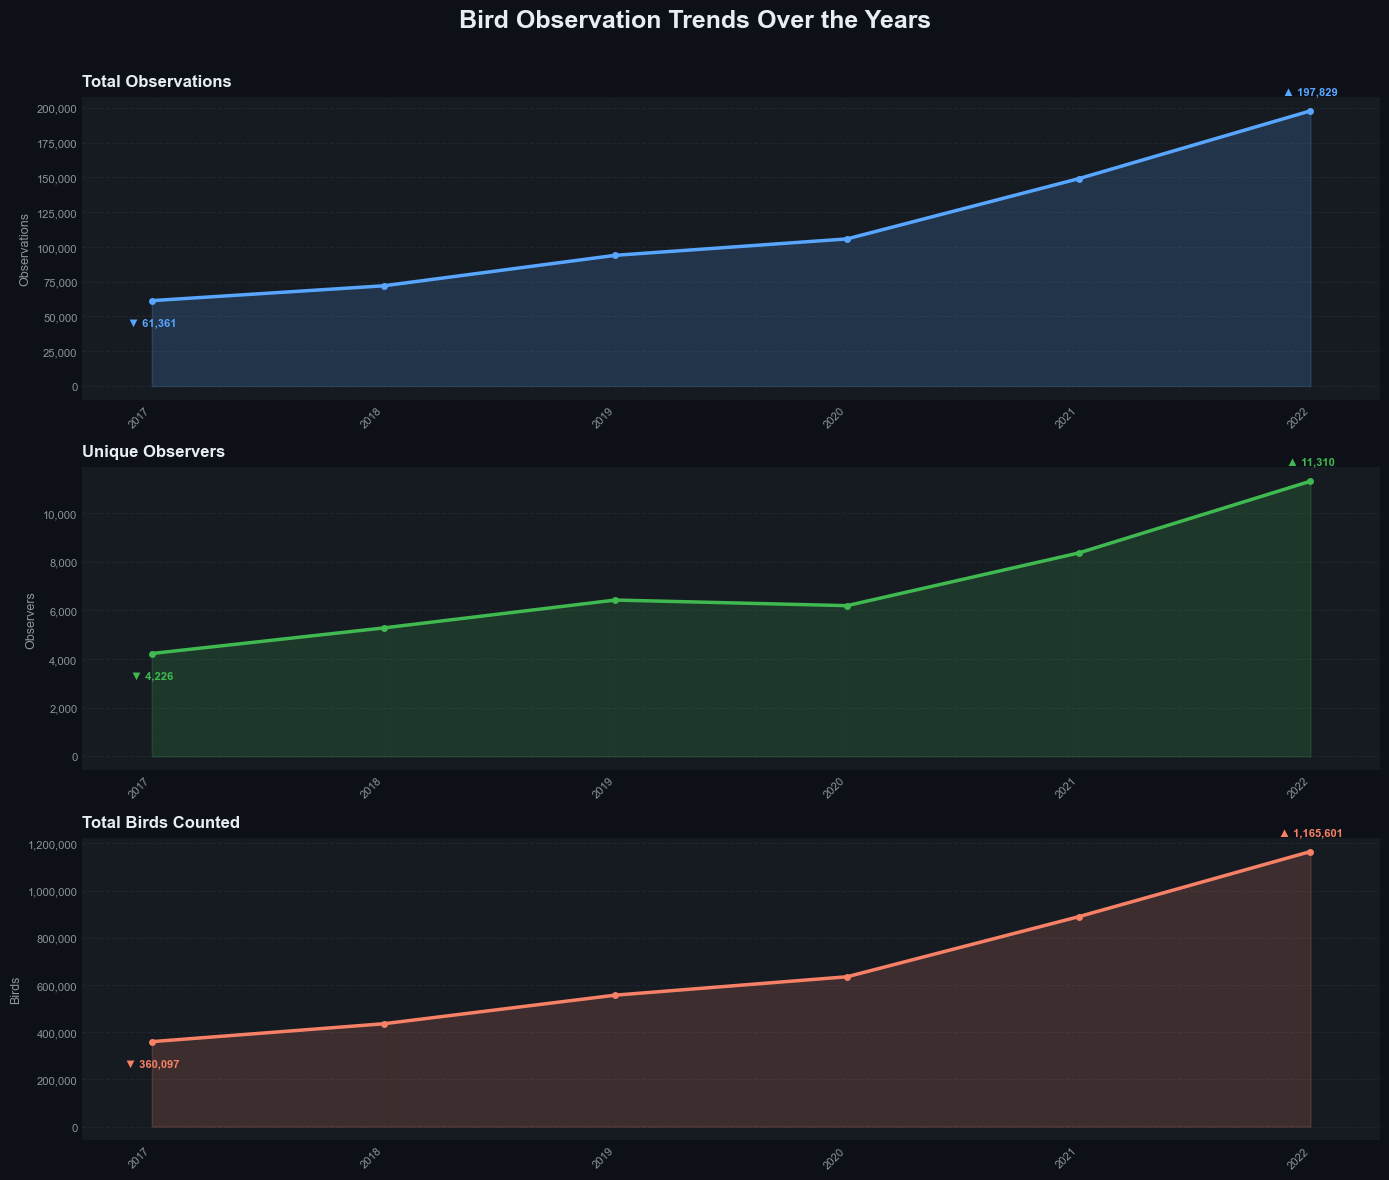

Plot saved to yearly_trends.png


In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(14, 12), facecolor='#0d1117')
fig.suptitle('Bird Observation Trends Over the Years', 
             fontsize=18, fontweight='bold', color='#e6edf3', y=0.98)

years = yearly_obs.index.astype(int)

metrics = [
    ('observations',     '#58a6ff', 'Total Observations',     'Observations'),
    ('unique_observers', '#3fb950', 'Unique Observers',        'Observers'),
    ('number_of_birds',  '#f78166', 'Total Birds Counted',     'Birds'),
]

for ax, (col, color, title, ylabel) in zip(axes, metrics):
    values = yearly_obs[col].values

    ax.set_facecolor('#161b22')
    ax.fill_between(years, values, alpha=0.18, color=color)
    ax.plot(years, values, color=color, linewidth=2.5, marker='o',
            markersize=5, markerfacecolor=color, markeredgewidth=0)

    # Annotate min/max
    max_idx, min_idx = values.argmax(), values.argmin()
    for idx, label in [(max_idx, f'▲ {values[max_idx]:,.0f}'), 
                       (min_idx, f'▼ {values[min_idx]:,.0f}')]:
        ax.annotate(label, xy=(years[idx], values[idx]),
                    xytext=(0, 12 if idx == max_idx else -18),
                    textcoords='offset points', ha='center',
                    fontsize=8, color=color, fontweight='bold')

    ax.set_title(title, fontsize=12, color='#e6edf3', pad=8, loc='left', fontweight='bold')
    ax.set_ylabel(ylabel, color='#8b949e', fontsize=9)
    ax.tick_params(colors='#8b949e', labelsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_xlim(years[0] - 0.3, years[-1] + 0.3)
    ax.set_xticks(years)
    ax.set_xticklabels([str(y) for y in years], rotation=45, ha='right')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')
    ax.grid(axis='y', color='#21262d', linewidth=0.8, linestyle='--')
    ax.grid(axis='x', color='#21262d', linewidth=0.4, linestyle=':')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('yearly_trends.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Plot saved to yearly_trends.png")

## 7. Distance to cities

In [17]:
# Load European cities
url = "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_populated_places.zip"
world = gpd.read_file(url)
europe = world[world.geometry.x.between(-25, 45) & world.geometry.y.between(34, 72)]
cities = europe[['NAME', 'ADM0NAME', 'geometry']].copy()
cities['lon'] = cities.geometry.x
cities['lat'] = cities.geometry.y
cities = cities.drop(columns='geometry').reset_index(drop=True)
cities

,NAME,ADM0NAME,lon,lat
0,L'Ariana,Tunisia,10.199998,36.866673
1,Jendouba,Tunisia,8.749999,36.500004
2,Kasserine,Tunisia,8.716698,35.216703
3,Sdid Bouzid,Tunisia,9.500004,35.016696
4,Siliana,Tunisia,9.383302,36.083304
...,...,...,...,...
1143,London,United Kingdom,-0.118668,51.501941
1144,Istanbul,Turkey,28.974277,41.017602
1145,Moscow,Russia,37.613577,55.754110
1146,Rome,Italy,12.481313,41.897902


In [18]:
df_migratory = combined_df

In [19]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# build KD-Tree on city coordinates ---
# convert lat/lon to radians for accurate distance calculation
cities_rad = np.radians(cities[['lat', 'lon']].values)
tree = cKDTree(cities_rad)

# find closest city for each bird observation ---
birds_rad = np.radians(df_migratory[['LATITUDE', 'LONGITUDE']].values)
distances, indices = tree.query(birds_rad, k=1)

# convert distance from radians to kilometers (Earth radius = 6371 km)
df_migratory['closest_city'] = cities['NAME'].iloc[indices].values
df_migratory['closest_city_country'] = cities['ADM0NAME'].iloc[indices].values
df_migratory['distance_km'] = np.round(distances * 6371, 2)

df_migratory

,COMMON NAME,SCIENTIFIC NAME,OBSERVATION COUNT,AGE/SEX,COUNTRY,COUNTRY CODE,STATE,STATE CODE,COUNTY,COUNTY CODE,ATLAS BLOCK,LOCALITY,LOCALITY ID,LOCALITY TYPE,LATITUDE,LONGITUDE,OBSERVATION DATE,OBSERVER ID,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE,obsDt,year,month,day_of_week,day_of_year,howMany,closest_city,closest_city_country,distance_km
0,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,CÃ¡diz,ES-AN-CD,NaN,Isla Tarifa.ES-Tarifa - 36.001x-5.611 - 20 Jan...,L5281087,P,36.001314,-5.610797,2017-01-20,obsr756857,S33804365,Traveling,2017-01-20,2017,1,4,20,2.0,Algeciras,Spain,22.80
1,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,NaN,Marismas del Odiel PNat--Isla de Saltes,L1419789,H,37.189895,-6.943853,2017-01-16,obsr271019,S33940654,Traveling,2017-01-16,2017,1,0,16,2.0,Huelva,Spain,6.90
2,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,NaN,Marismas del Odiel PNat--Isla de Saltes,L1419789,H,37.189895,-6.943853,2017-01-16,obsr427437,S33751745,Traveling,2017-01-16,2017,1,0,16,2.0,Huelva,Spain,6.90
3,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,NaN,Marismas del Odiel PNat--Isla de Saltes,L1419789,H,37.189895,-6.943853,2017-01-16,obsr546444,S34018122,Traveling,2017-01-16,2017,1,0,16,2.0,Huelva,Spain,6.90
4,Eurasian Whimbrel,Numenius phaeopus,3.0,NaN,Spain,ES,Canarias,ES-CN,Fuerteventura,ES-CN-FVT,NaN,Salinas del Carmen,L3189830,H,28.367192,-13.869656,2017-01-21,obsr777138,S33908528,Traveling,2017-01-21,2017,1,5,21,3.0,Rabat,Morocco,1003.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
876678,Black Tern,Chlidonias niger,2.0,NaN,Portugal,PT,Faro,PT-08,LoulÃ©,PT-08-LO,NaN,PN Ria Formosa--Quinta do Ludo--Ãrea Geral,L1099654,H,37.025529,-7.997092,2022-09-29,obsr288132,S119628247,Traveling,2022-09-29,2022,9,3,272,2.0,Faro,Portugal,7.16
876679,Black Tern,Chlidonias niger,1.0,NaN,Portugal,PT,Faro,PT-08,Silves,PT-08-SI,NaN,Lagoa dos Salgados,L962500,H,37.094690,-8.331370,2022-09-11,obsr555427,S118487968,Traveling,2022-09-11,2022,9,6,254,1.0,Portimão,Portugal,22.87
876680,Black Tern,Chlidonias niger,3.0,NaN,Romania,RO,Tulcea,RO-TL,NaN,NaN,NaN,Danube Delta Biosphere Reserve--Bird Sanctuary,L6219391,H,45.091944,29.403148,2022-09-02,obsr235897,S118369228,Traveling,2022-09-02,2022,9,4,245,3.0,Tulcea,Romania,68.49
876681,Black Tern,Chlidonias niger,1.0,NaN,Spain,ES,Canarias,ES-CN,Fuerteventura,ES-CN-FVT,NaN,Salinas del Carmen,L3189830,H,28.367192,-13.869656,2022-10-14,obsr1130704,S120667335,Traveling,2022-10-14,2022,10,4,287,1.0,Rabat,Morocco,1003.72


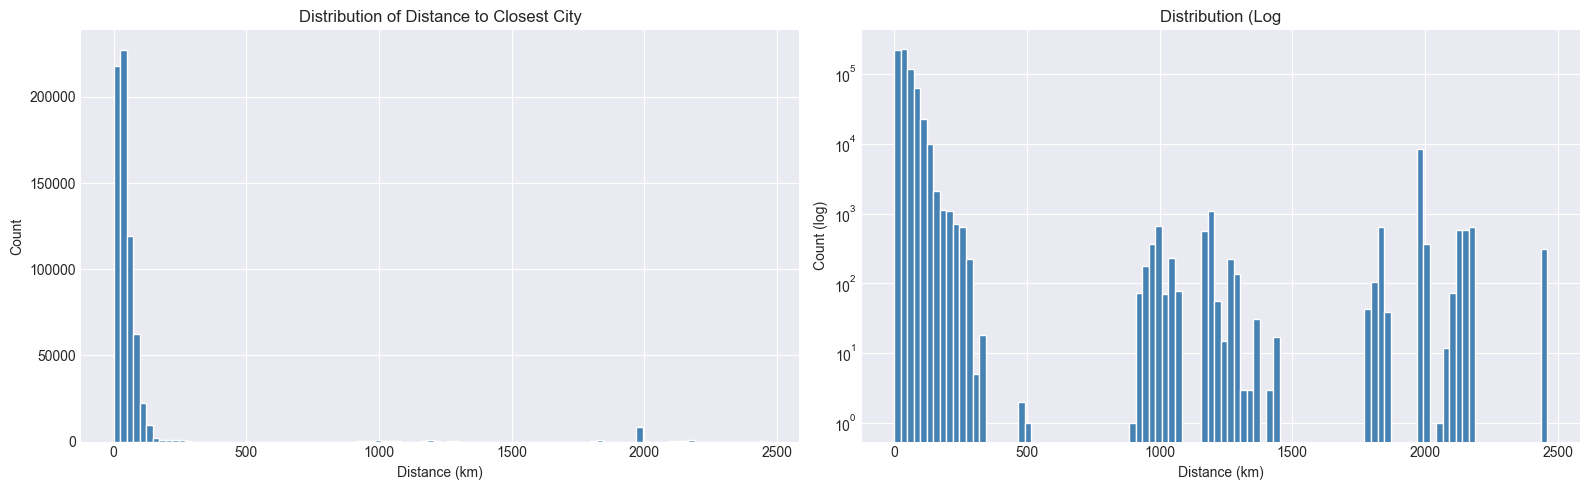

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# histogram
axes[0].hist(df_migratory['distance_km'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Distance to Closest City')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Count')

# log scale histogram (useful if data is right-skewed)
axes[1].hist(df_migratory['distance_km'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Distribution (Log')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Count (log)')


plt.tight_layout()
plt.savefig("distance_distribution.png", dpi=150)
plt.show()

### Distance Aggregations

The following cells calculate the average distance to the closest city across three groupings:
1. **Per year** — how the average distance changes over time
2. **Per species** — average across all years for each species
3. **Per species per year** — the most granular breakdown

In [21]:
# --- 1. Average distance to closest city per year ---
dist_by_year = (
    df_migratory
    .dropna(subset=['distance_km', 'year'])
    .groupby('year')['distance_km']
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values('year')
)
dist_by_year['year'] = dist_by_year['year'].astype(int)

print("Average distance to closest city per year:")
print(dist_by_year.to_string(index=False))

Average distance to closest city per year:
 year  mean_distance_km  median_distance_km  n_observations
 2017         95.395968               36.01           61361
 2018         96.337666               35.81           72027
 2019         86.931782               36.14           93957
 2020         81.213313               35.68          105754
 2021         83.031998               36.47          149076
 2022         73.378260               35.85          197829


In [22]:
# --- 2. Average distance to closest city per species (across all years) ---
dist_by_species = (
    df_migratory
    .dropna(subset=['distance_km', 'COMMON NAME'])
    .groupby('COMMON NAME')['distance_km']
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values('mean_distance_km', ascending=False)
)

print("Average distance to closest city per species (all years combined):")
print(dist_by_species.to_string(index=False))

Average distance to closest city per species (all years combined):
           COMMON NAME  mean_distance_km  median_distance_km  n_observations
     Eurasian Whimbrel        321.544883              77.345           11140
            Sanderling        158.837963              34.620           85484
              Red Knot        129.793454              38.990           39126
      Curlew Sandpiper        119.619915              35.260           36594
          Little Stint         97.890082              35.650           51689
                  Ruff         74.425911              37.930          109964
        Wood Sandpiper         52.292325              35.170           74871
       Green Sandpiper         48.148268              35.560          173660
              Garganey         45.450144              32.550           52675
European Honey-buzzard         42.706787              38.840           44529
            Black Tern         41.300699              33.490             272


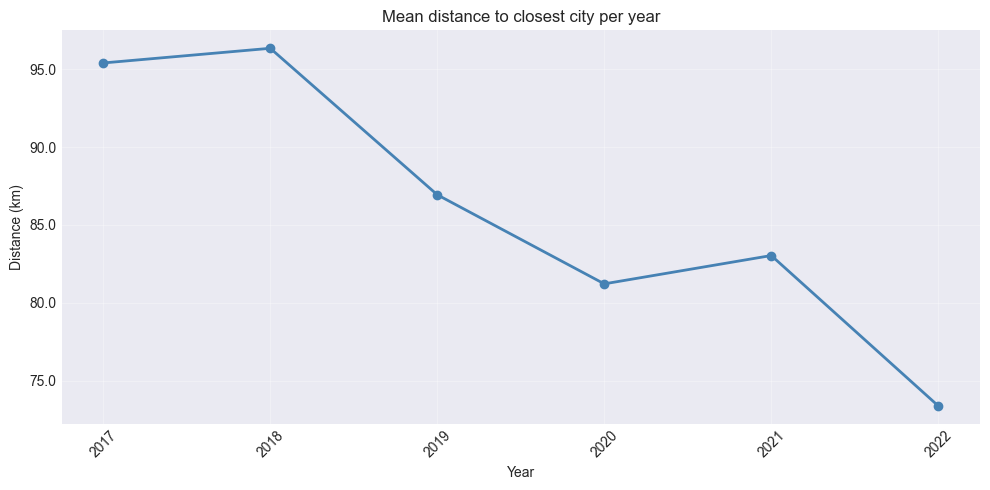

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(dist_by_year['year'], dist_by_year['mean_distance_km'],
        color='steelblue', marker='o', linewidth=2, markersize=6)

ax.set_xticks(dist_by_year['year'])
ax.set_xticklabels(dist_by_year['year'], rotation=45)
ax.set_title('Mean distance to closest city per year')
ax.set_xlabel('Year')
ax.set_ylabel('Distance (km)')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.1f}'))

plt.tight_layout()
plt.show()

In [24]:
# --- 3. Average distance to closest city per species per year ---
dist_by_species_year = (
    df_migratory
    .dropna(subset=['distance_km', 'COMMON NAME', 'year'])
    .groupby(['COMMON NAME', 'year'])['distance_km']
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values(['COMMON NAME', 'year'])
)
dist_by_species_year['year'] = dist_by_species_year['year'].astype(int)

print("Average distance to closest city per species per year:")
print(dist_by_species_year.to_string(index=False))

# Optionally pivot for a cleaner species × year view
pivot_mean = dist_by_species_year.pivot(index='COMMON NAME', columns='year', values='mean_distance_km').round(2)
print("\nPivot table — mean distance (km) by species × year:")
print(pivot_mean.to_string())

Average distance to closest city per species per year:
           COMMON NAME  year  mean_distance_km  median_distance_km  n_observations
            Black Tern  2022         41.300699              33.490             272
      Curlew Sandpiper  2017        157.199957              35.030            3004
      Curlew Sandpiper  2018        122.924719              34.620            3785
      Curlew Sandpiper  2019        107.419646              34.855            4854
      Curlew Sandpiper  2020        112.330849              35.260            6045
      Curlew Sandpiper  2021        150.485339              37.830            6932
      Curlew Sandpiper  2022         99.904219              35.260           11974
     Eurasian Whimbrel  2017        278.135817              85.510            1566
     Eurasian Whimbrel  2018        362.190702              85.510            1809
     Eurasian Whimbrel  2019        314.691806              79.600            2016
     Eurasian Whimbrel  2020    

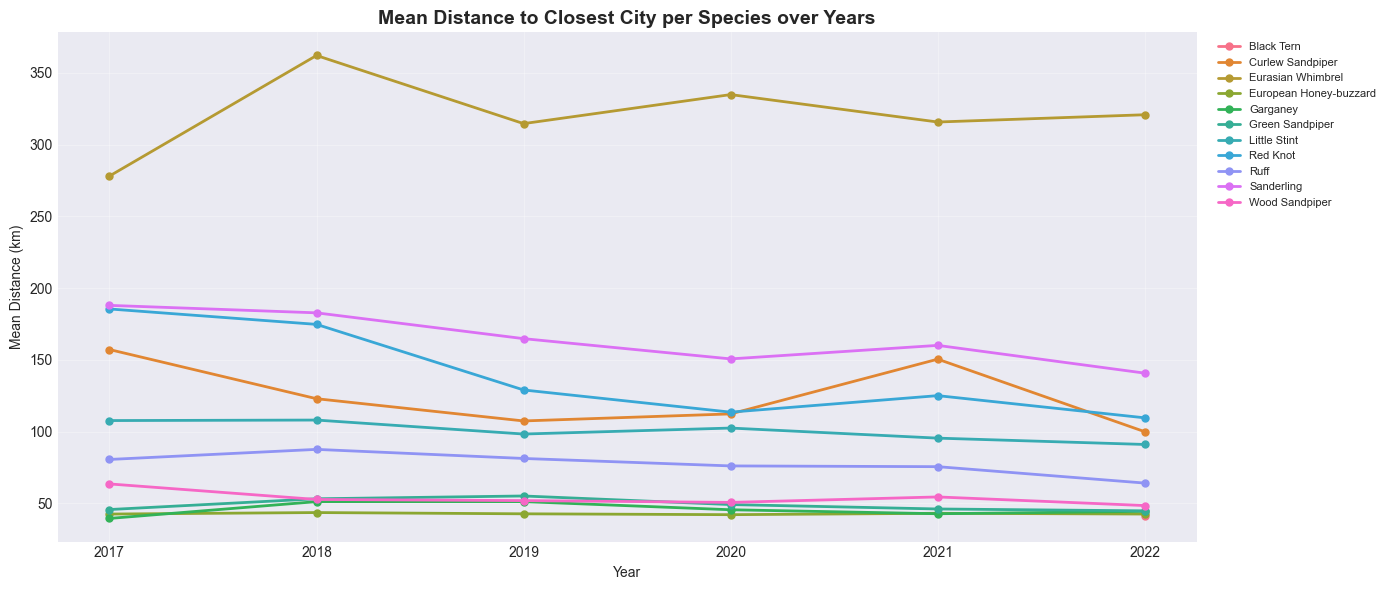

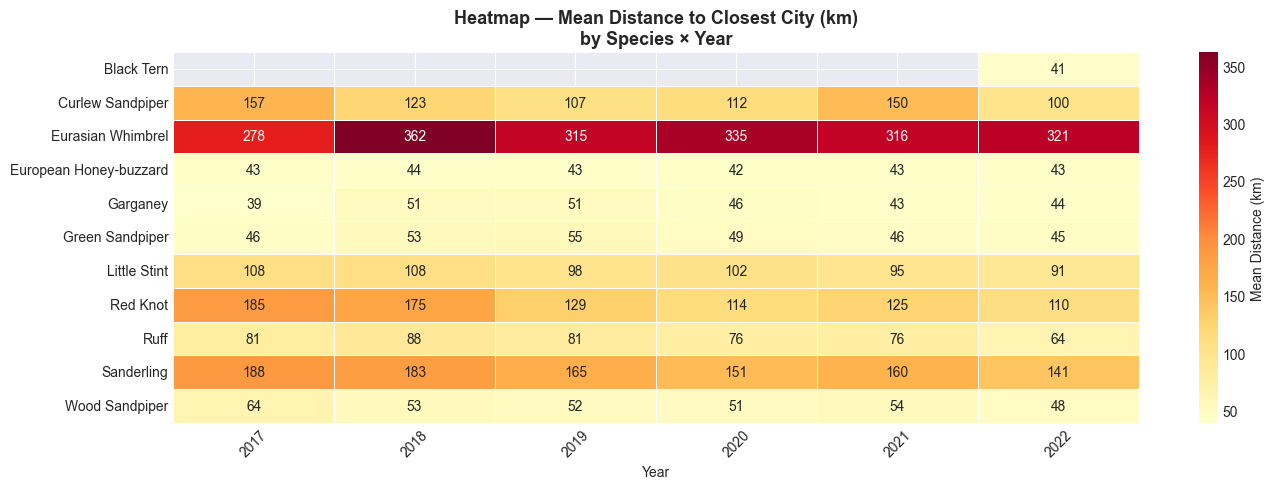

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Colour palette ──────────────────────────────────────────────────────────
species_list = dist_by_species_year['COMMON NAME'].unique()
palette = dict(zip(species_list, sns.color_palette("husl", len(species_list))))

# ============================================================
# PLOT 1 — Line plot: mean distance per species over years
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))

for species, grp in dist_by_species_year.groupby('COMMON NAME'):
    ax.plot(grp['year'], grp['mean_distance_km'],
            marker='o', linewidth=2, markersize=5,
            label=species, color=palette[species])

ax.set_title('Mean Distance to Closest City per Species over Years', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Mean Distance (km)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, framealpha=0.7)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dist_species_year_lineplot.png', dpi=150)
plt.show()

# ============================================================
# PLOT 2 — Heatmap: pivot_mean (species × year)
# ============================================================
fig, ax = plt.subplots(figsize=(14, max(5, len(species_list) * 0.45)))

sns.heatmap(
    pivot_mean,
    ax=ax,
    cmap='YlOrRd',
    annot=True, fmt='.0f',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Mean Distance (km)'}
)

ax.set_title('Heatmap — Mean Distance to Closest City (km)\nby Species × Year',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('dist_species_year_heatmap.png', dpi=150)
plt.show()


In [26]:
print(df_migratory['distance_km'].describe())
print(f"\nMedian:  {df_migratory['distance_km'].median():.2f} km")
print(f"Skewness: {df_migratory['distance_km'].skew():.2f}")
print(f"% within 10km:  {(df_migratory['distance_km'] <= 10).mean()*100:.1f}%")
print(f"% within 50km:  {(df_migratory['distance_km'] <= 50).mean()*100:.1f}%")
print(f"% within 100km: {(df_migratory['distance_km'] <= 100).mean()*100:.1f}%")

count    680004.000000
mean         83.004531
std         270.402656
min           0.060000
25%          20.840000
50%          35.990000
75%          59.440000
max        2460.870000
Name: distance_km, dtype: float64

Median:  35.99 km
Skewness: 6.67
% within 10km:  8.8%
% within 50km:  66.2%
% within 100km: 92.3%


### this is only done for migrating birds
this part of the notebook maps the subgroups of migrating birds from the reference file (nika_datasciproj -> datasets -> bird_species_migration.csv) to the ebird data

In [27]:
# THIS CELL IS ONLY RUN FOR MIGRATING BIRDS !!



# Load the bird species reference file
reference_file = '/Users/dazedinthecity/Documents/GitHub/ceu-ds-project-groupB-2026/datasets/birds/bird_species_migration.csv' 

try:
    bird_reference = pd.read_csv(reference_file)
    print("✓ Bird species reference file loaded successfully!")
    print(f"\nReference file contains {len(bird_reference)} rows")
    print(f"\nColumns: {bird_reference.columns.tolist()}")
except FileNotFoundError:
    print(f"Error: Could not find '{reference_file}'")
    print("Please update the reference_file path in the cell above.")

# mapping subgroup from reference file to ebird dataset
migration_map = dict(zip(
    bird_reference['bird_species'].str.lower(),
    bird_reference['migration_period'] # look at the comments below. enter " " from those lines refer to this line
))
# to group by day/nighttime activity (diurnal and nocturnal) enter " bird_reference['migration_group'] "
# to group by migrating period (fall/spring migrating birds) enter " bird_reference['migration_period'] "
# this is the only line that changes when choosing the subgroups. the rest stays the same.


# Map migration groups to observations
combined_df['migration_group'] = combined_df['COMMON NAME'].str.lower().map(migration_map)

# get rid of this subgroup because of the low samples
combined_df = combined_df[combined_df['migration_group'] != 'diurnal & nocturnal']
combined_df['migration_group'].unique()

✓ Bird species reference file loaded successfully!

Reference file contains 12 rows

Columns: ['bird_species', 'ebird_code', 'migration_period', 'migration_group']


array(['F', 'S'], dtype=object)

In [28]:
# ── 1. Average distance per migration group (all years combined) ─────────────
dist_by_group = (
    combined_df
    .dropna(subset=['distance_km', 'migration_group'])
    .groupby('migration_group')['distance_km'] # this is where u choose each group
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values('mean_distance_km', ascending=False)
)

print("Average distance to closest city per migration group:")
print(dist_by_group.to_string(index=False))

# ── 2. Average distance per migration group per year ─────────────────────────
dist_by_group_year = (
    combined_df
    .dropna(subset=['distance_km', 'migration_group', 'year'])
    .groupby(['migration_group', 'year'])['distance_km']
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values(['migration_group', 'year'])
)
dist_by_group_year['year'] = dist_by_group_year['year'].astype(int)

print("\nAverage distance to closest city per migration group per year:")
print(dist_by_group_year.to_string(index=False))

# ── 3. Average distance per migration group per species ───────────────────────
dist_by_group_species = (
    combined_df
    .dropna(subset=['distance_km', 'migration_group', 'COMMON NAME'])
    .groupby(['migration_group', 'COMMON NAME'])['distance_km']
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values(['migration_group', 'mean_distance_km'], ascending=[True, False])
)

print("\nAverage distance to closest city per migration group per species:")
print(dist_by_group_species.to_string(index=False))

# ── Pivot: migration group × year ─────────────────────────────────────────────
pivot_group_year = dist_by_group_year.pivot(
    index='migration_group', columns='year', values='mean_distance_km'
).round(2)

print("\nPivot table — mean distance (km) by migration group × year:")
print(pivot_group_year.to_string())

Average distance to closest city per migration group:
migration_group  mean_distance_km  median_distance_km  n_observations
              S         91.543795               35.68          362120
              F         73.276963               36.68          317884

Average distance to closest city per migration group per year:
migration_group  year  mean_distance_km  median_distance_km  n_observations
              F  2017         81.221291              36.940           28881
              F  2018         83.520147              37.790           34098
              F  2019         76.577716              37.250           44130
              F  2020         72.022322              36.110           51750
              F  2021         72.707952              36.720           69649
              F  2022         66.342039              35.830           89376
              S  2017        107.999996              35.435           32480
              S  2018        107.860557              34.820     

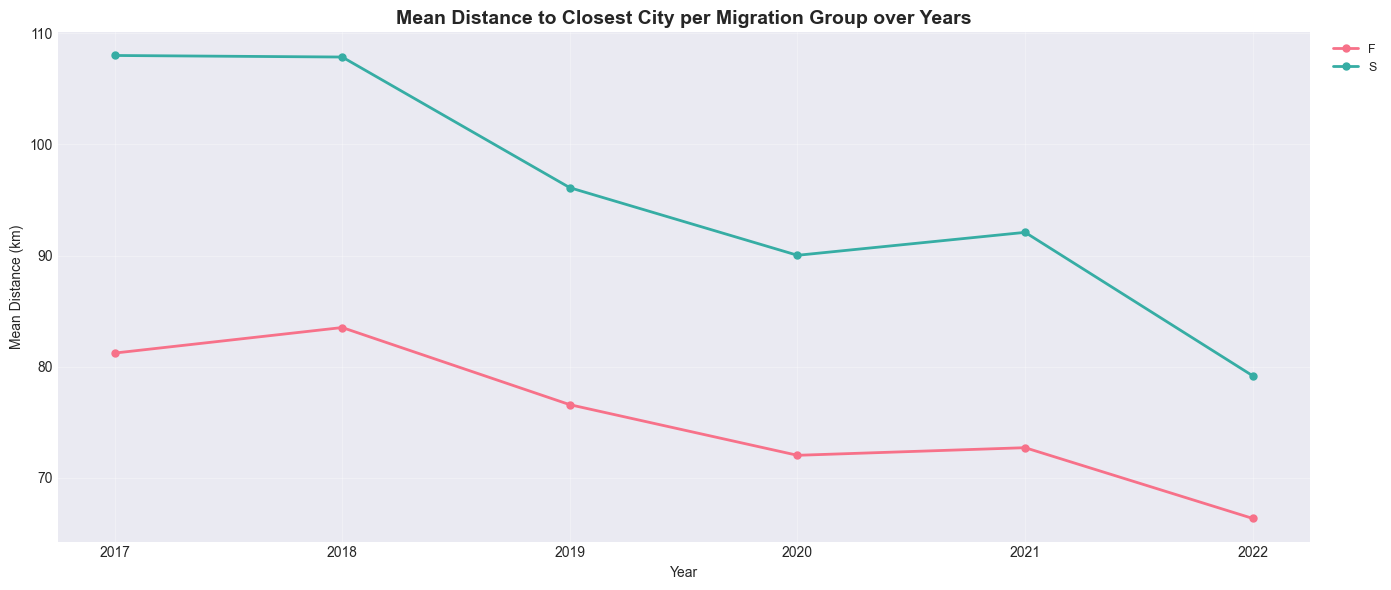

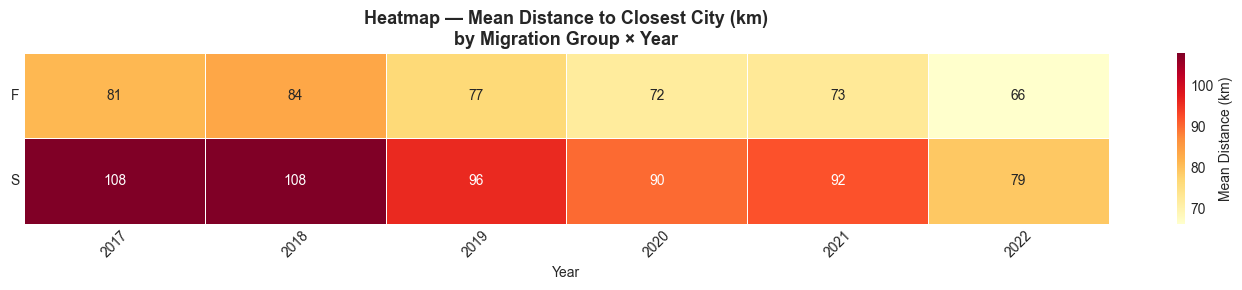

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Colour palette ───────────────────────────────────────────────────────────
group_list = dist_by_group_year['migration_group'].unique()
palette = dict(zip(group_list, sns.color_palette("husl", len(group_list))))

# ============================================================
# PLOT 1 — Line plot: mean distance per migration group over years
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))

for group, grp in dist_by_group_year.groupby('migration_group'):
    ax.plot(grp['year'], grp['mean_distance_km'],
            marker='o', linewidth=2, markersize=5,
            label=group, color=palette[group])

ax.set_title('Mean Distance to Closest City per Migration Group over Years', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Mean Distance (km)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, framealpha=0.7)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dist_group_year_lineplot.png', dpi=150)
plt.show()

# ============================================================
# PLOT 2 — Heatmap: migration group × year
# ============================================================
fig, ax = plt.subplots(figsize=(14, max(3, len(group_list) * 0.8)))

sns.heatmap(
    pivot_group_year,
    ax=ax,
    cmap='YlOrRd',
    annot=True, fmt='.0f',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Mean Distance (km)'}
)

ax.set_title('Heatmap — Mean Distance to Closest City (km)\nby Migration Group × Year',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('dist_group_year_heatmap.png', dpi=150)
plt.show()